In [1]:
import time
t1 = time.time()

import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import shap

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[1], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-07-07 04:14:23.730002: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

HLdata_path = "/root/data/mucollider/two_boosted/3TeV/test_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/3TeV/test_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

##### select BTag work point at WP70 (BitNumber 1) #####

BTag_leading = ((HLdata_file['BTag_leading'][:])&2)
BTag_subleading = ((HLdata_file['BTag_subleading'][:])&2)

##### include other high level features data #####

HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': HLdata.append(BTag_leading)
    elif feature=='BTag_subleading': HLdata.append(BTag_subleading)
    else: HLdata.append(HLdata_file[feature][:])
HLdata = np.array(HLdata).T
print('shape of high level data:', HLdata.shape)

LLdata = LLdata_file['particle_info'][:]
print('shape of low level data:', LLdata.shape)

target = HLdata_file['target_sigbg'][:]
print('shape of target:', target.shape)

#### Do training data and validation data split #####

HL_train, HL_val, LL_train, LL_val, y_train, y_val = train_test_split(HLdata, LLdata, target, test_size=0.2, random_state=2330, shuffle=True)
print("\nAfter training validation data split:")
print("HL training data: ", HL_train.shape, "HL validation data: ", HL_val.shape)
print("LL training data: ", LL_train.shape, "LL validation data: ", LL_val.shape)
print("training target: ", y_train.shape, "validation target: ", y_val.shape)

shape of high level data: (347538, 16)
shape of low level data: (347538, 160)
shape of target: (347538,)

After training validation data split:
HL training data:  (278030, 16) HL validation data:  (69508, 16)
LL training data:  (278030, 160) LL validation data:  (69508, 160)
training target:  (278030,) validation target:  (69508,)


In [4]:
##### load the model #####

model = models.load_model("/root/data/mucollider/two_boosted/3TeV/ML_model/model_mucollider_10.h5")

2026-07-07 04:14:27.421203: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


In [5]:
background_indices = np.random.choice(HL_train.shape[0], 200, replace=False)
background = [HL_train[background_indices], LL_train[background_indices]]

explainer = shap.DeepExplainer(model, background)

test_data = [HL_val, LL_val]
shap_values = explainer.shap_values(test_data)

/root/miniconda3/envs/tf/lib/python3.10/site-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
2026-07-07 04:14:28.817963: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
/root/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


In [6]:
SYMBOL = {
    'm_J_leading':     r'$M(J_1)$',
    'm_J_subleading':  r'$M(J_2)$',
    'pt_J_leading':    r'$p_T(J_1)$',
    'pt_J_subleading': r'$p_T(J_2)$',
    'missET':          r'$E_T^{\rm miss}$',
    'X_HH':            r'$X_{HH}$',
    'M_JJ':            r'$M_{JJ}$',
    'pT_JJ':           r'$p_T^{JJ}$',
    'dEta_JJ':         r'$\Delta\eta_{JJ}$',
    'BTag_leading':    r'${\rm BTag}(J_1)$',
    'BTag_subleading': r'${\rm BTag}(J_2)$',
    'H_0': r'$H_0$', 'H_1': r'$H_1$', 'S_0': r'$S_0$', 'S_1': r'$S_1$',
    'LB_1': r'$LB_1$',
    'particle_cloud': 'particle cloud',
}

streams = {}
for i, nm in enumerate([str(n) for n in HLfeatures]):
    streams[nm] = (shap_values[0][:, i].astype(float).flatten(), HL_val[:, i].astype(float))

def _arr(s):
    a = np.asarray(s)
    return a[..., 0] if a.shape[-1] == 1 and a.ndim >= 2 else a
    
sv_LL = _arr(shap_values[1]).reshape(len(LL_val), 2, 20, 4).astype(np.float32)
streams['particle_cloud'] = (sv_LL.astype(float).sum(axis=(1, 2, 3)), np.zeros(len(LL_val)))    ### setting the color of the particle cloud to zero

order = sorted(streams, key=lambda nm: -float(np.mean(np.abs(streams[nm][0]))))
n = len(order)

saved /root/data/mucollider/two_boosted/generated_fig/fig_shap_boosted.pdf


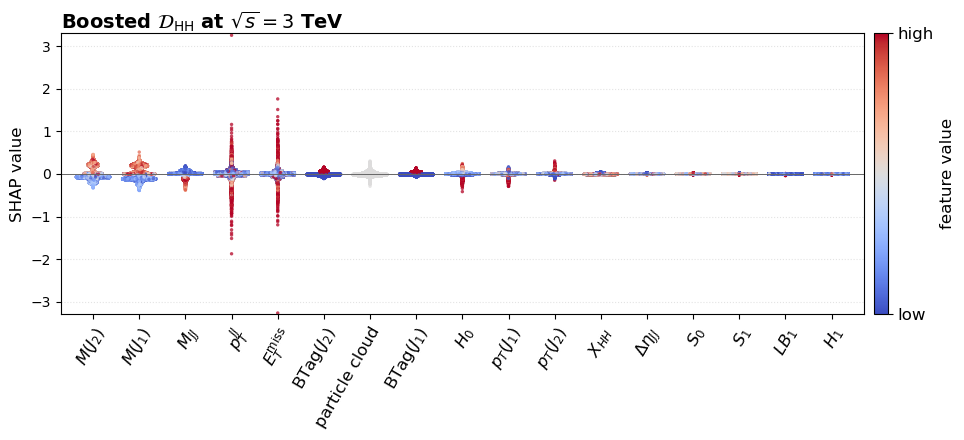

In [9]:
def swarm_offsets(vals, row_height=0.40, nbins=100):
    vals = np.asarray(vals); N = len(vals)
    rng = np.max(vals) - np.min(vals)
    if N == 0 or rng < 1e-12:
        return np.zeros(N)
    quant = np.round(nbins * (vals - np.min(vals)) / rng).astype(int)
    inds = np.argsort(quant + np.random.RandomState(0).randn(N) * 1e-6)
    layer, last, ys = 0, -1, np.zeros(N)
    for k in inds:
        if quant[k] != last:
            layer = 0
        ys[k] = np.ceil(layer / 2) * ((-1) ** layer)
        layer += 1; last = quant[k]
    return ys * (0.9 * row_height / max(1.0, np.max(np.abs(ys))))

fig, ax = plt.subplots(1, 1, figsize=(9.8, 4.5))
cmap = plt.get_cmap('coolwarm')
for i, nm in enumerate(order):
    sv, X = streams[nm]
    q_lo, q_hi = np.quantile(X, [0.05, 0.95])
    colour = (np.full(len(X), 0.5) if q_hi - q_lo < 1e-12
              else np.clip((X - q_lo) / (q_hi - q_lo), 0, 1))
    ax.scatter(i + swarm_offsets(sv), sv, c=colour, cmap=cmap, vmin=0, vmax=1,
               s=6.0, alpha=0.75, edgecolors='none', rasterized=True)
ax.axhline(0, color='0.4', lw=0.7)
ax.set_xticks(np.arange(n))
ax.set_xticklabels([SYMBOL.get(nm, nm) for nm in order],
                   rotation=60, ha='right', rotation_mode='anchor', fontsize=12)
ax.set_ylabel('SHAP value', fontsize=12)
ax.set_title(r'Boosted $\mathcal{D}_{\rm HH}$ at $\sqrt{s}=3$ TeV', fontsize=14, fontweight='bold', loc='left', pad=3)
ax.grid(axis='y', linestyle=':', alpha=0.35)
ax.set_xlim(-0.7, n - 0.3)
ymax = np.ceil(10 * max(np.max(np.abs(streams[nm][0])) for nm in order)) / 10
ax.set_ylim(-ymax, ymax)
ax.tick_params(axis='x', which='minor', bottom=False, top=False)

cb = fig.colorbar(ScalarMappable(norm=Normalize(0, 1), cmap=cmap), ax=ax, ticks=[0, 1], pad=0.012, fraction=0.028)
cb.ax.set_yticklabels(['low', 'high'], fontsize=12)
cb.set_label('feature value', fontsize=12)
cb.ax.tick_params(which='minor', right=False)

fig.tight_layout()

OUTPDF = "/root/data/mucollider/two_boosted/generated_fig/fig_shap_boosted.pdf"
fig.savefig(OUTPDF, bbox_inches='tight')
print(f'saved {OUTPDF}')

plt.show()

In [8]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:232.9162(s)
